# **PART A: DATASET PREPARATION**

In [23]:
# Import Required Libraries
print('NAME:     AKHIL C\nROLL NO:  24BAD007')
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import ReLU
import matplotlib.pyplot as plt
import numpy as np
import os

NAME:     AKHIL C
ROLL NO:  24BAD007


In [13]:
# Dataset paths
train_dir = "D:\\DL_LABS\\seg_train"
test_dir = "D:\\DL_LABS\\seg_test"

# Image parameters
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

In [14]:
# Load training dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load validation dataset
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load test dataset
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.


In [17]:
# Class names
class_names = train_dataset.class_names
print("Classes:", class_names)
print("Number of classes:", len(class_names))

for images, labels in train_dataset.take(1):
    print("\nImage batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of classes: 6

Image batch shape: (32, 150, 150, 3)
Label batch shape: (32,)


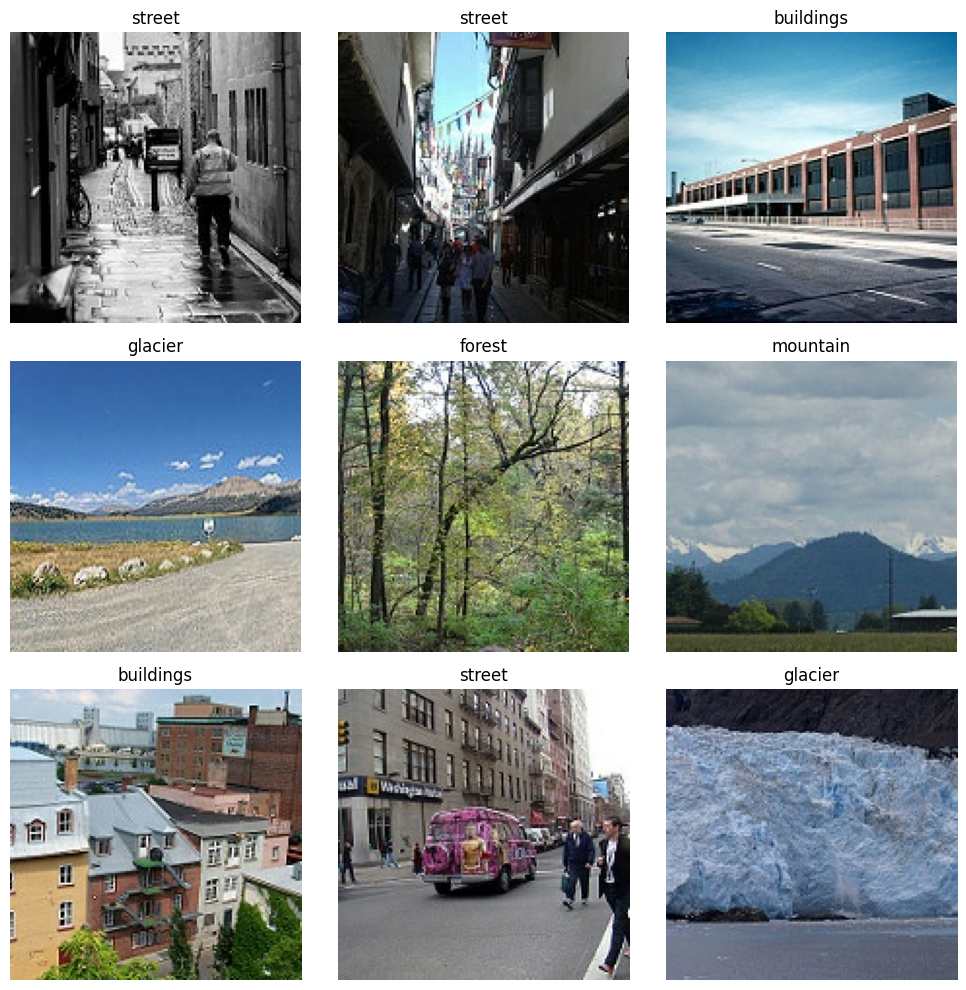

In [18]:
# Display sample images
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Normalize pixel values
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y))

validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y))

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y))

# **PART B: CNN MODEL IMPLEMENTATION**

In [30]:
model = Sequential([

    # First convolution block
    Conv2D(
        32,
        (3, 3),
        padding='same',
        input_shape=(150, 150, 3)
    ),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D((2, 2)),

    # Second convolution block
    Conv2D(
        64,
        (3, 3),
        padding='same'
    ),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D((2, 2)),

    # Third convolution block
    Conv2D(
        128,
        (3, 3),
        padding='same'
    ),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D((2, 2)),

    # Fully connected layers
    Flatten(),

    Dense(128),
    BatchNormalization(),
    ReLU(),

    Dropout(0.5),

    # Output layer
    Dense(6, activation='softmax')
])

model.summary()

c:\Users\Akhil\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,403,974 (20.61 MB)

 Trainable params: 5,403,270 (20.61 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

# **PART C: MODEL TRAINING AND EVALUATION**

In [32]:
# Train the model
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20
)

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 207s 583ms/step - accuracy: 0.6877 - loss: 0.8572 - val_accuracy: 0.3642 - val_loss: 1.7764
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 192s 546ms/step - accuracy: 0.7815 - loss: 0.6028 - val_accuracy: 0.7687 - val_loss: 0.6060
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 203s 578ms/step - accuracy: 0.8165 - loss: 0.5136 - val_accuracy: 0.7206 - val_loss: 0.7464
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 194s 552ms/step - accuracy: 0.8362 - loss: 0.4514 - val_accuracy: 0.6878 - val_loss: 0.8670
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 193s 550ms/step - accuracy: 0.8616 - loss: 0.3863 - val_accuracy: 0.8236 - val_loss: 0.4986
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 140s 398ms/step - accuracy: 0.8807 - loss: 0.3370 - val_accuracy: 0.7612 - val_loss: 0.7119
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 130s 371ms/step - accuracy: 0.8937 - loss: 0.2919 - val_accuracy: 0.7003 - val_loss: 1.0016
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 132s 375ms/step - accuracy: 0.9133 -

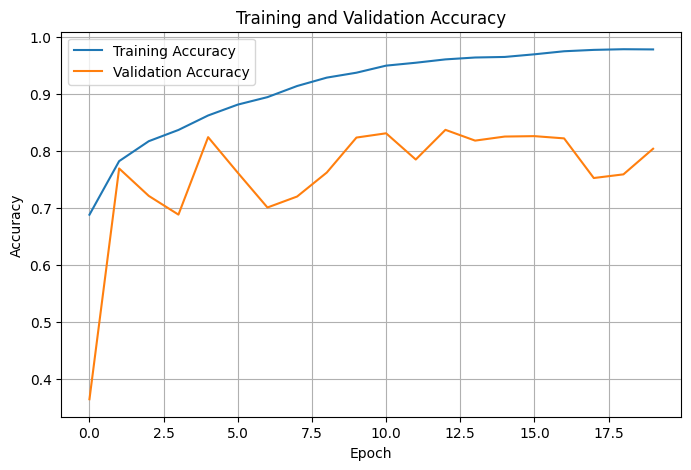

In [33]:
# Accuracy vs Epoch
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid()

plt.show()

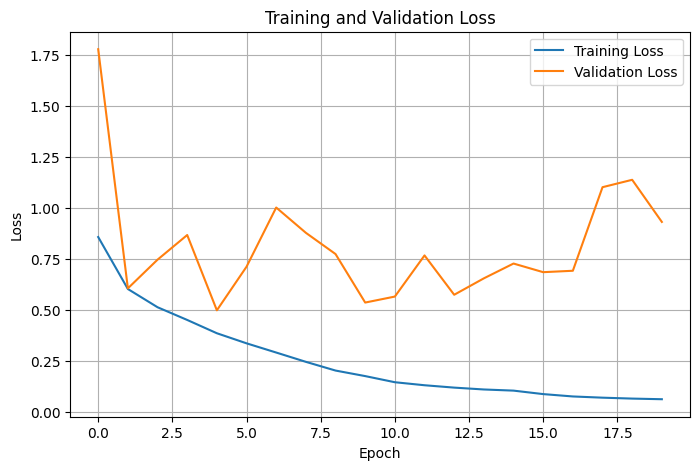

In [34]:
# Loss vs Epoch
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid()

plt.show()

In [35]:
print("\n===== FINAL TRAINING RESULTS =====")
print(f"Training Accuracy   : {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Training Loss       : {history.history['loss'][-1] * 100:.4f}")
print(f"Validation Accuracy : {history.history['val_accuracy'][-1] * 100:.2f}%")
print(f"Validation Loss     : {history.history['val_loss'][-1]:.4f}")


===== FINAL TRAINING RESULTS =====
Training Accuracy   : 97.74%
Training Loss       : 6.3419
Validation Accuracy : 80.33%
Validation Loss     : 0.9311


In [36]:
# Model  Evaluation
test_loss, test_accuracy = model.evaluate(test_dataset)

print("\n===== TEST RESULTS =====")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.7873 - loss: 1.0300

===== TEST RESULTS =====
Test Loss     : 1.0300
Test Accuracy : 78.73%


# **PART D: PERFORMANCE ANALYSIS**

In [37]:
# Generate Predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion Matrix

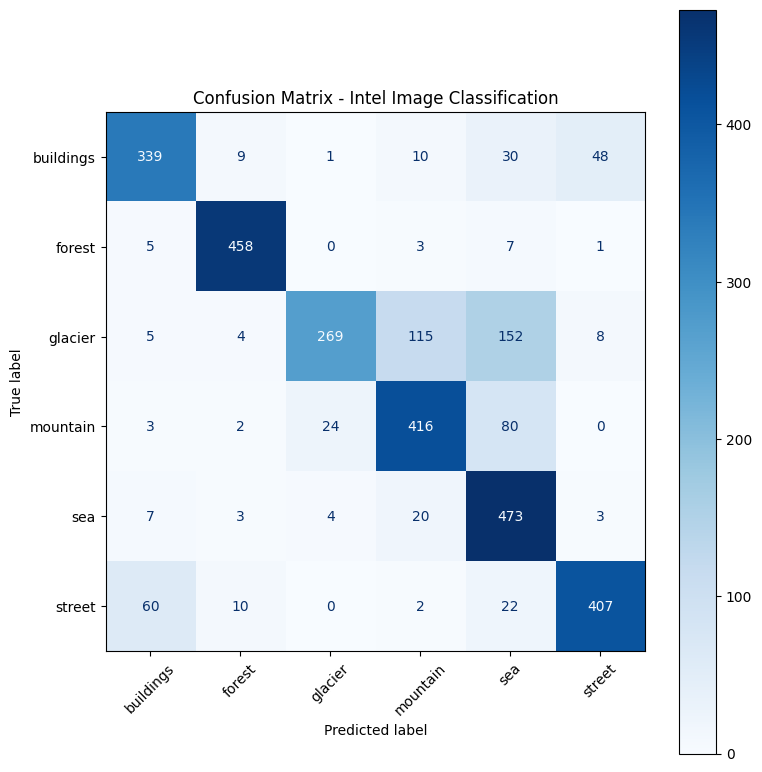

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    ax=ax,
    cmap='Blues',
    xticks_rotation=45
)

plt.title("Confusion Matrix - Intel Image Classification")
plt.tight_layout()
plt.show()

# Misclassified images

Number of misclassified images: 638


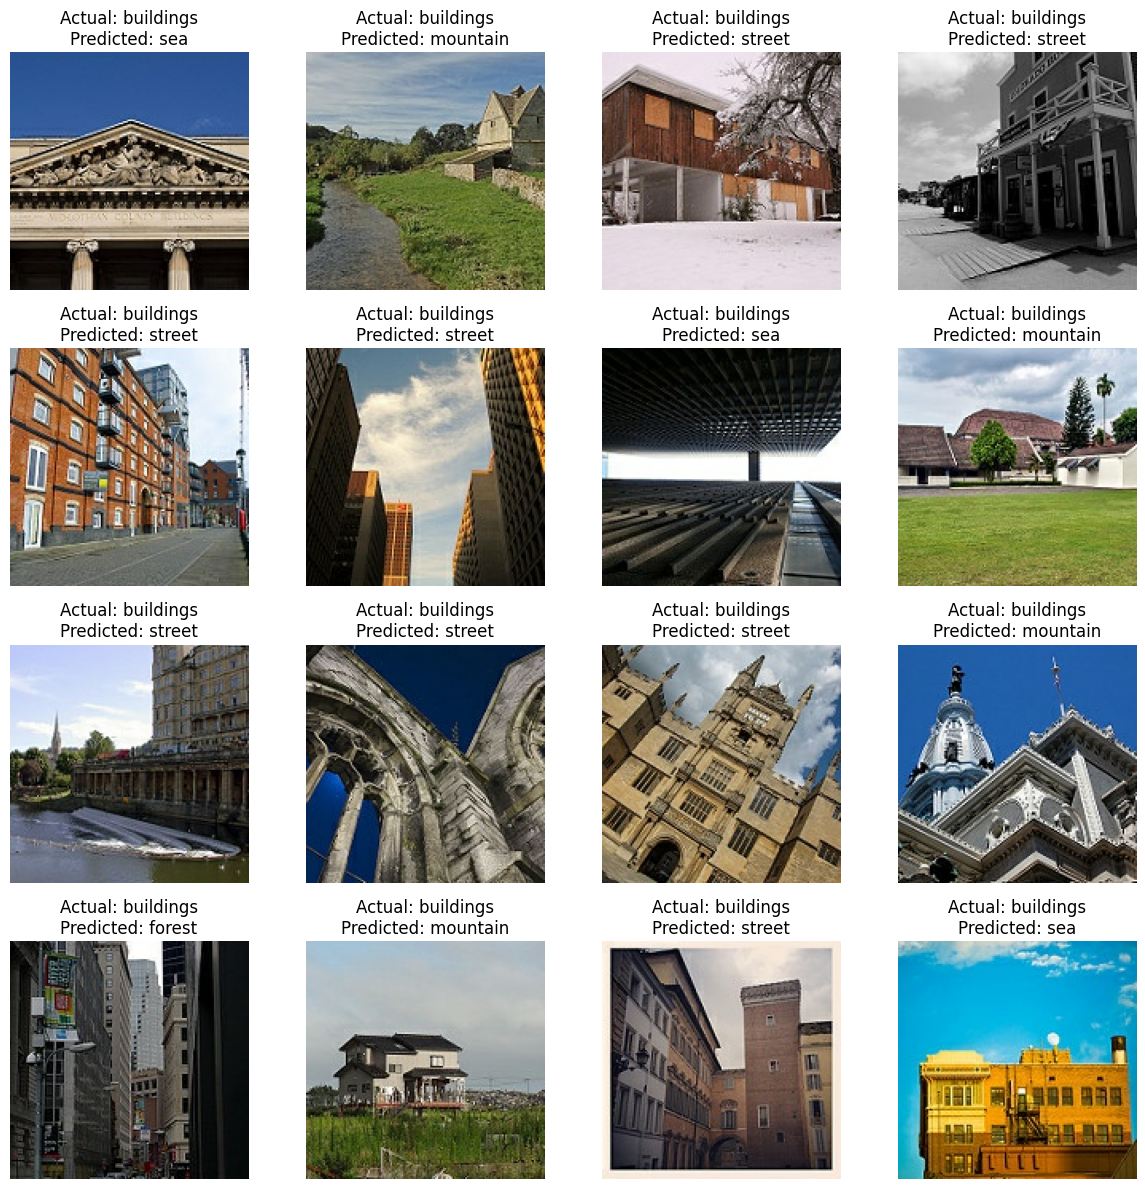

In [42]:
misclassified_indices = np.where(y_true != y_pred)[0]
print("Number of misclassified images:", len(misclassified_indices))

all_test_images = []
all_test_labels = []

for images, labels in test_dataset:
    all_test_images.extend(images.numpy())
    all_test_labels.extend(labels.numpy())

all_test_images = np.array(all_test_images)
all_test_labels = np.array(all_test_labels)

plt.figure(figsize=(12, 12))

num_images = min(16, len(misclassified_indices))

for i in range(num_images):
    index = misclassified_indices[i]

    ax = plt.subplot(4, 4, i + 1)

    plt.imshow(all_test_images[index])

    actual = class_names[y_true[index]]
    predicted = class_names[y_pred[index]]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# **Strengths and Limitations of CNNs**

### **Strengths**

- Automatically learns important image features.
- Preserves spatial relationships between pixels.
- Requires less manual feature engineering.
- Works effectively for image classification.
- Can learn complex patterns using multiple convolution layers.

### **Limitations**

- Requires a large amount of training data for strong performance.
- Training can require significant computational resources.
- CNNs can suffer from overfitting.
- Performance depends on architecture and hyperparameter selection.
- Training from scratch can take considerable time.